<a href="https://colab.research.google.com/github/angeloapmc1-dev/TelecomX_Final/blob/main/TelecomX_MachineLearning_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

df = pd.read_csv("/content/datos_tratados.csv")
df.drop(columns=['customerID'], inplace=True, errors='ignore')

print("Datos cargados correctamente")
df.head()

Datos cargados correctamente


,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,1,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,1,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,1,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [4]:
columnas_texto = df.select_dtypes(include=['object']).columns
df_final = pd.get_dummies(df, columns=columnas_texto, drop_first=True)

print("Variables transformadas")
df_final.head()

Variables transformadas


,Churn,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,phone.PhoneService_Yes,phone.MultipleLines_No phone service,...,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,0,9,65.6,593.30,False,True,True,True,False,...,False,True,False,False,True,False,True,False,False,True
1,0,0,9,59.9,542.40,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,1,0,4,73.9,280.85,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
3,1,1,13,98.0,1237.85,True,True,False,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1,1,3,83.9,267.40,False,True,False,True,False,...,False,True,False,False,False,False,True,False,False,True


In [5]:
from sklearn.model_selection import train_test_split

X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba: {X_test.shape[0]} filas")

Entrenamiento: 4922 filas
Prueba: 2110 filas


In [6]:
from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier(random_state=42)
modelo.fit(X_train, y_train)

print("¡Modelo entrenado con éxito!")

¡Modelo entrenado con éxito!


In [7]:
from sklearn.metrics import accuracy_score

predicciones = modelo.predict(X_test)
precision = accuracy_score(y_test, predicciones)

print(f"La precisión del modelo es: {precision * 100:.2f}%")

La precisión del modelo es: 78.67%


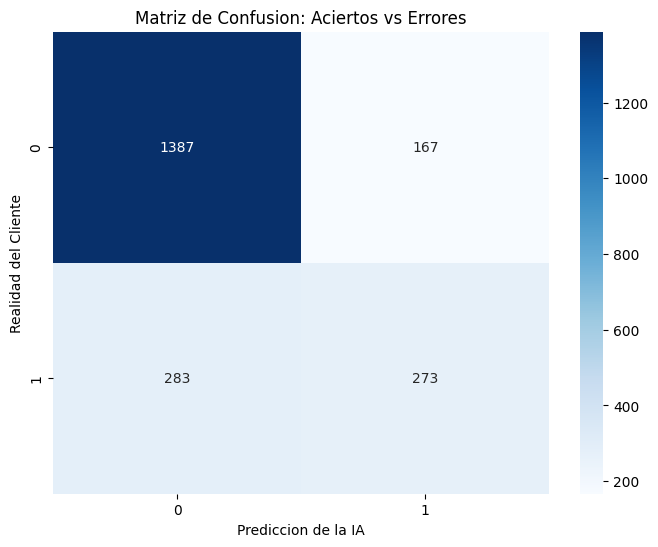

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predicciones)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediccion de la IA')
plt.ylabel('Realidad del Cliente')
plt.title('Matriz de Confusion: Aciertos vs Errores')
plt.show()

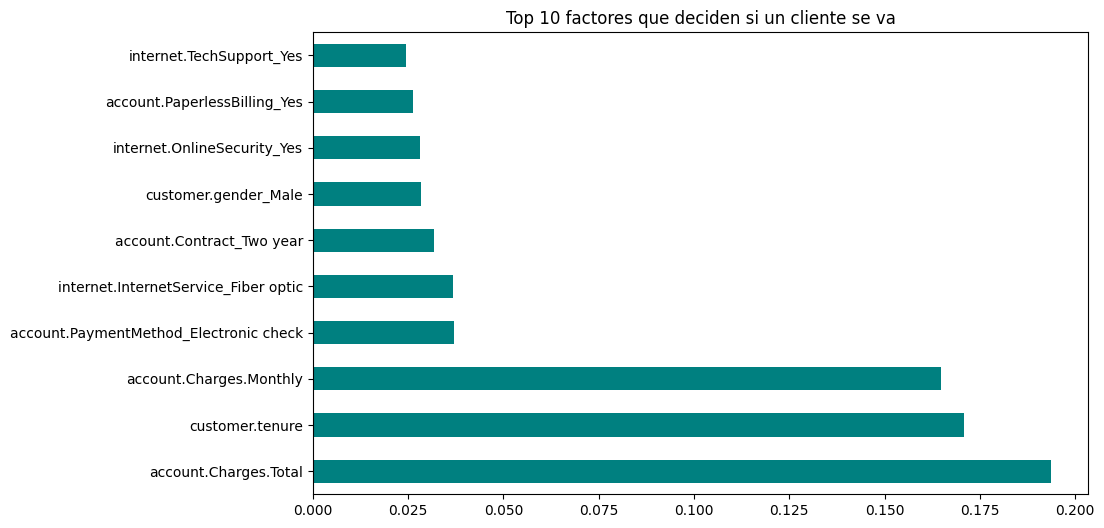

In [9]:
import pandas as pd

importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importancias.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 factores que deciden si un cliente se va')
plt.show()

In [10]:
import numpy as np

nuevo_cliente = X_test.iloc[[0]]
prediccion_final = modelo.predict(nuevo_cliente)

if prediccion_final[0] == 1:
    print("La IA predice que este cliente se va de la empresa")
else:
    print("La IA predice que este cliente se queda")

La IA predice que este cliente se queda


In [11]:
from sklearn.metrics import classification_report

reporte = classification_report(y_test, predicciones)

print("Reporte Final del Desafio:")
print(reporte)

Reporte Final del Desafio:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1554
           1       0.62      0.49      0.55       556

    accuracy                           0.79      2110
   macro avg       0.73      0.69      0.70      2110
weighted avg       0.78      0.79      0.78      2110

